In [1]:
# =============================================================================
# Binary Search Tree Reward Visualization
# =============================================================================
# Author: Robert Gardner
# Date: ......
#
# Description:
# This program runs simulations of a modified approach to (BSTs) binary search trees, 
# The default settings of this program are designed to prove there is a solution to
# a famous GOOGLE interview question explained here: ............................
#
# Features:
# 1. BST Generation:
#    - bst(): Returns rewards array for a given seed.
#    - bst_with_graph(): Builds BST as a networkx graph and plots it.
#
# 2. Visualization:
#    - plot_rewards(): Plots rewards for a single seed, weighted averages, or mean across all seeds.
#    - reward_table(): Displays a full table of node rewards across seeds, optionally weighted.
#
# 3. Interactivity:
#    - Interactive seed slider using ipywidgets to dynamically update the BST
#      visualization and reward plots.
#
# 4. Customization:
#    - rewards_list: Set reward values by depth.
#    - all_seeds: Range of seeds for averaging rewards.
#    - edge_cases / rounding_optimisations: Optional tweaks for specific nodes.
#
# Usage:
# 1. Run the notebook or script in a Jupyter environment.
# 2. Use the interactive slider at the top to select the seed and visualize
#    the resulting BST and rewards.
# 3. Call plot_rewards() or reward_table() to explore rewards for different
#    seeds or weighted averages.
#
# Notes:
# - Seeds 38–62 tend to maximize average rewards in the default configuration.
# - Nodes deeper in the BST have lower rewards; edge cases can be manually
#   overridden.
# =============================================================================


import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display
from scipy.optimize import minimize
import pandas as pd

# ------------------- Constants -------------------
arr = np.arange(1, 101)                                                      #max range 2^10=2048 (1,2049) (depth of 12)
rewards_list = [5, 4, 3, 2, 1, 0, -1, -2, -3, -4, -5, -6]                               
all_seeds = list(range(38, 63))
weights = None

optimise_data = [] #[(38, 38, None, 'down'), (38, 70, None, 'down'), (38, 86, None, 'down'), (38, 94, None, 'down'), (38, 98, None, 'down'), (38, 19, 'up', 'down'), (38, 29, None, 'down'), (38, 34, 'up', None), (38, 31, None, 'down'), (38, 24, 'up', 'down'), (38, 27, 'up', None), (38, 21, None, 'down'), (38, 14, 'up', 'down'), (38, 17, 'up', None), (38, 11, None, 'down'), (38, 9, 'up', None), (38, 4, None, 'down'), (38, 7, 'up', None), (39, 70, 'up', 'down'), (39, 86, None, 'down'), (39, 94, None, 'down'), (39, 98, None, 'down'), (39, 54, 'up', None), (39, 46, 'up', None), (39, 42, 'up', None), (39, 39, 'up', None), (39, 34, 'up', 'down'), (39, 37, 'up', None), (39, 31, None, 'down'), (39, 24, 'up', 'down'), (39, 27, 'up', None), (39, 21, None, 'down'), (39, 19, 'up', None), (39, 14, 'up', 'down'), (39, 17, 'up', None), (39, 11, None, 'down'), (39, 9, 'up', None), (39, 4, None, 'down'), (39, 7, 'up', None), (40, 40, None, 'down'), (40, 86, 'up', 'down'), (40, 94, None, 'down'), (40, 98, None, 'down'), (40, 78, 'up', None), (40, 74, 'up', None), (40, 71, 'up', None), (40, 55, 'up', None), (40, 47, 'up', None), (40, 43, 'up', None), (40, 35, 'up', 'down'), (40, 38, 'up', None), (40, 32, None, 'down'), (40, 25, 'up', 'down'), (40, 28, 'up', None), (40, 22, None, 'down'), (40, 15, 'up', 'down'), (40, 18, 'up', None), (40, 12, None, 'down'), (40, 5, 'up', 'down'), (40, 8, 'up', None), (40, 2, None, 'down'), (41, 86, 'up', 'down'), (41, 94, None, 'down'), (41, 98, None, 'down'), (41, 78, 'up', None), (41, 74, 'up', None), (41, 56, 'up', 'down'), (41, 64, None, 'down'), (41, 68, None, 'down'), (41, 48, 'up', None), (41, 44, 'up', None), (41, 41, 'up', None), (41, 20, None, 'down'), (41, 36, 'up', 'down'), (41, 39, 'up', None), (41, 33, None, 'down'), (41, 31, 'up', None), (41, 28, 'up', 'down'), (41, 25, 'up', None), (41, 22, None, 'down'), (41, 15, 'up', 'down'), (41, 18, 'up', None), (41, 12, None, 'down'), (41, 5, 'up', 'down'), (41, 8, 'up', None), (41, 2, None, 'down'), (42, 42, None, 'down'), (42, 72, None, 'down'), (42, 94, 'up', 'down'), (42, 98, None, 'down'), (42, 90, 'up', None), (42, 87, 'up', None), (42, 79, 'up', None), (42, 75, 'up', None), (42, 57, 'up', 'down'), (42, 65, None, 'down'), (42, 69, None, 'down'), (42, 49, 'up', None), (42, 45, 'up', None), (42, 21, 'up', 'down'), (42, 37, 'up', 'down'), (42, 40, 'up', None), (42, 34, None, 'down'), (42, 32, 'up', None), (42, 29, 'up', 'down'), (42, 26, 'up', None), (42, 23, None, 'down'), (42, 10, None, 'down'), (42, 16, None, 'down'), (42, 19, 'up', None), (42, 13, 'up', 'down'), (42, 5, 'up', 'down'), (42, 8, 'up', None), (42, 2, None, 'down'), (43, 72, 'up', 'down'), (43, 94, 'up', 'down'), (43, 98, None, 'down'), (43, 90, 'up', None), (43, 87, 'up', None), (43, 79, 'up', None), (43, 75, 'up', None), (43, 57, None, 'down'), (43, 65, None, 'down'), (43, 69, None, 'down'), (43, 50, 'up', 'down'), (43, 54, None, 'down'), (43, 46, 'up', None), (43, 43, 'up', None), (43, 32, 'up', 'down'), (43, 38, None, 'down'), (43, 41, 'up', None), (43, 35, 'up', 'down'), (43, 29, 'up', 'down'), (43, 26, 'up', None), (43, 23, None, 'down'), (43, 21, 'up', None), (43, 10, None, 'down'), (43, 16, None, 'down'), (43, 19, 'up', None), (43, 13, 'up', 'down'), (43, 5, 'up', 'down'), (43, 8, 'up', None), (43, 2, None, 'down'), (44, 44, None, 'down'), (44, 94, 'up', 'down'), (44, 98, None, 'down'), (44, 90, 'up', None), (44, 80, 'up', 'down'), (44, 84, None, 'down'), (44, 76, 'up', None), (44, 73, 'up', None), (44, 58, None, 'down'), (44, 66, None, 'down'), (44, 70, None, 'down'), (44, 51, 'up', 'down'), (44, 55, None, 'down'), (44, 47, 'up', None), (44, 33, 'up', 'down'), (44, 39, None, 'down'), (44, 42, 'up', None), (44, 36, 'up', 'down'), (44, 30, 'up', 'down'), (44, 27, 'up', None), (44, 24, None, 'down'), (44, 11, 'up', 'down'), (44, 17, None, 'down'), (44, 20, 'up', None), (44, 14, 'up', 'down'), (44, 8, 'up', 'down'), (44, 5, 'up', None), (44, 2, None, 'down'), (45, 94, 'up', 'down'), (45, 98, None, 'down'), (45, 90, 'up', None), (45, 80, 'up', 'down'), (45, 84, None, 'down'), (45, 76, 'up', None), (45, 66, 'up', 'down'), (45, 70, None, 'down'), (45, 62, 'up', None), (45, 52, 'up', 'down'), (45, 56, None, 'down'), (45, 48, 'up', None), (45, 45, 'up', None), (45, 22, None, 'down'), (45, 34, None, 'down'), (45, 40, None, 'down'), (45, 43, 'up', None), (45, 37, 'up', 'down'), (45, 31, 'up', 'down'), (45, 25, 'up', 'down'), (45, 11, 'up', 'down'), (45, 17, None, 'down'), (45, 20, 'up', None), (45, 14, 'up', 'down'), (45, 8, 'up', 'down'), (45, 5, 'up', None), (45, 2, None, 'down'), (46, 46, None, 'down'), (46, 74, None, 'down'), (46, 88, None, 'down'), (46, 98, 'up', 'down'), (46, 95, 'up', None), (46, 91, 'up', None), (46, 81, 'up', 'down'), (46, 85, None, 'down'), (46, 77, 'up', None), (46, 67, 'up', 'down'), (46, 71, None, 'down'), (46, 63, 'up', None), (46, 53, 'up', 'down'), (46, 57, None, 'down'), (46, 49, 'up', None), (46, 23, 'up', 'down'), (46, 35, None, 'down'), (46, 41, None, 'down'), (46, 44, 'up', None), (46, 38, 'up', 'down'), (46, 32, 'up', 'down'), (46, 26, 'up', 'down'), (46, 20, 'up', 'down'), (46, 14, 'up', 'down'), (46, 11, 'up', None), (46, 8, 'up', 'down'), (46, 5, 'up', None), (46, 2, None, 'down'), (47, 74, 'up', 'down'), (47, 88, None, 'down'), (47, 98, 'up', 'down'), (47, 95, 'up', None), (47, 91, 'up', None), (47, 81, 'up', 'down'), (47, 85, None, 'down'), (47, 77, 'up', None), (47, 67, 'up', 'down'), (47, 71, None, 'down'), (47, 63, 'up', None), (47, 60, 'up', None), (47, 53, None, 'down'), (47, 57, None, 'down'), (47, 50, 'up', 'down'), (47, 47, 'up', None), (47, 44, 'up', 'down'), (47, 38, 'up', 'down'), (47, 32, 'up', 'down'), (47, 26, 'up', 'down'), (47, 23, 'up', None), (47, 20, 'up', 'down'), (47, 14, 'up', 'down'), (47, 11, 'up', None), (47, 8, 'up', 'down'), (47, 5, 'up', None), (47, 2, None, 'down'), (48, 48, None, 'down'), (48, 88, 'up', 'down'), (48, 98, 'up', 'down'), (48, 95, 'up', None), (48, 91, 'up', None), (48, 81, None, 'down'), (48, 85, None, 'down'), (48, 78, 'up', 'down'), (48, 75, 'up', None), (48, 68, 'up', 'down'), (48, 72, None, 'down'), (48, 64, 'up', None), (48, 61, 'up', None), (48, 54, None, 'down'), (48, 58, None, 'down'), (48, 51, 'up', 'down'), (48, 45, 'up', 'down'), (48, 39, 'up', 'down'), (48, 33, 'up', 'down'), (48, 27, 'up', 'down'), (48, 21, 'up', 'down'), (48, 15, 'up', 'down'), (48, 9, 'up', 'down'), (48, 3, 'up', 'down'), (49, 88, 'up', 'down'), (49, 98, 'up', 'down'), (49, 95, 'up', None), (49, 91, 'up', None), (49, 81, None, 'down'), (49, 85, None, 'down'), (49, 78, 'up', 'down'), (49, 62, 'up', 'down'), (49, 72, 'up', 'down'), (49, 69, 'up', None), (49, 65, 'up', None), (49, 55, None, 'down'), (49, 59, None, 'down'), (49, 52, 'up', 'down'), (49, 49, 'up', None), (49, 24, None, 'down'), (49, 46, 'up', 'down'), (49, 40, 'up', 'down'), (49, 37, 'up', None), (49, 30, None, 'down'), (49, 34, None, 'down'), (49, 27, 'up', 'down'), (49, 21, 'up', 'down'), (49, 15, 'up', 'down'), (49, 9, 'up', 'down'), (49, 3, 'up', 'down'), (50, 50, None, 'up'), (50, 88, 'up', 'up'), (50, 94, None, 'down'), (50, 98, None, 'up'), (50, 91, 'down', 'down'), (50, 81, None, 'down'), (50, 85, None, 'up'), (50, 78, 'up', 'down'), (50, 75, 'up', None), (50, 62, None, 'down'), (50, 72, 'up', 'down'), (50, 69, 'up', None), (50, 65, 'up', None), (50, 59, 'up', 'down'), (50, 53, 'down', 'up'), (50, 25, 'down', 'up'), (50, 37, None, 'down'), (50, 47, 'down', 'up'), (50, 44, 'up', None), (50, 40, 'up', None), (50, 34, 'up', 'down'), (50, 28, 'down', 'up'), (50, 22, 'down', 'up'), (50, 16, 'up', 'down'), (50, 13, 'up', None), (50, 6, None, 'down'), (50, 10, None, 'down'), (50, 3, 'down', 'up'), (51, 76, 'up', 'down'), (51, 98, 'up', 'down'), (51, 92, 'up', 'down'), (51, 89, 'up', None), (51, 82, None, 'down'), (51, 86, None, 'down'), (51, 79, 'up', 'down'), (51, 63, None, 'down'), (51, 73, 'up', 'down'), (51, 70, 'up', None), (51, 66, 'up', None), (51, 60, 'up', 'down'), (51, 54, 'up', 'down'), (51, 51, 'up', None), (51, 38, 'up', 'down'), (51, 48, 'up', 'down'), (51, 45, 'up', None), (51, 41, 'up', None), (51, 31, None, 'down'), (51, 35, None, 'down'), (51, 28, 'up', 'down'), (51, 25, 'up', None), (51, 12, None, 'down'), (51, 22, 'up', 'down'), (51, 19, 'up', None), (51, 15, 'up', None), (51, 9, 'up', 'down'), (51, 3, 'up', 'down'), (52, 52, None, 'down'), (52, 98, 'up', 'down'), (52, 92, 'up', 'down'), (52, 86, 'up', 'down'), (52, 80, 'up', 'down'), (52, 77, 'up', None), (52, 64, None, 'down'), (52, 74, 'up', 'down'), (52, 71, 'up', None), (52, 67, 'up', None), (52, 61, 'up', 'down'), (52, 55, 'up', 'down'), (52, 39, 'up', 'down'), (52, 49, 'up', 'down'), (52, 46, 'up', None), (52, 42, 'up', None), (52, 32, None, 'down'), (52, 36, None, 'down'), (52, 29, 'up', 'down'), (52, 13, 'up', 'down'), (52, 23, 'up', 'down'), (52, 20, 'up', None), (52, 16, 'up', None), (52, 6, None, 'down'), (52, 10, None, 'down'), (52, 3, 'up', 'down'), (53, 98, 'up', 'down'), (53, 92, 'up', 'down'), (53, 86, 'up', 'down'), (53, 80, 'up', 'down'), (53, 74, 'up', 'down'), (53, 68, 'up', 'down'), (53, 62, 'up', 'down'), (53, 56, 'up', 'down'), (53, 53, 'up', None), (53, 26, None, 'down'), (53, 40, None, 'down'), (53, 50, 'up', 'down'), (53, 47, 'up', None), (53, 43, 'up', None), (53, 33, 'up', 'down'), (53, 37, None, 'down'), (53, 29, 'up', None), (53, 13, 'up', 'down'), (53, 23, 'up', 'down'), (53, 20, 'up', None), (53, 16, 'up', None), (53, 6, None, 'down'), (53, 10, None, 'down'), (53, 3, 'up', 'down'), (54, 54, None, 'down'), (54, 78, None, 'down'), (54, 90, None, 'down'), (54, 96, None, 'down'), (54, 99, 'up', None), (54, 93, 'up', 'down'), (54, 87, 'up', 'down'), (54, 81, 'up', 'down'), (54, 75, 'up', 'down'), (54, 69, 'up', 'down'), (54, 63, 'up', 'down'), (54, 57, 'up', 'down'), (54, 27, 'up', 'down'), (54, 41, None, 'down'), (54, 51, 'up', 'down'), (54, 48, 'up', None), (54, 44, 'up', None), (54, 34, 'up', 'down'), (54, 38, None, 'down'), (54, 30, 'up', None), (54, 20, 'up', 'down'), (54, 24, None, 'down'), (54, 16, 'up', None), (54, 13, 'up', None), (54, 6, None, 'down'), (54, 10, None, 'down'), (54, 3, 'up', 'down'), (55, 78, 'up', 'down'), (55, 90, None, 'down'), (55, 96, None, 'down'), (55, 99, 'up', None), (55, 93, 'up', 'down'), (55, 87, 'up', 'down'), (55, 81, 'up', 'down'), (55, 75, 'up', 'down'), (55, 69, 'up', 'down'), (55, 66, 'up', None), (55, 63, 'up', 'down'), (55, 60, 'up', None), (55, 57, None, 'down'), (55, 55, 'up', None), (55, 48, 'up', 'down'), (55, 52, None, 'down'), (55, 44, 'up', None), (55, 34, 'up', 'down'), (55, 38, None, 'down'), (55, 30, 'up', None), (55, 27, 'up', None), (55, 20, 'up', 'down'), (55, 24, None, 'down'), (55, 16, 'up', None), (55, 13, 'up', None), (55, 6, None, 'down'), (55, 10, None, 'down'), (55, 3, 'up', 'down'), (56, 56, None, 'down'), (56, 90, 'up', 'down'), (56, 96, None, 'down'), (56, 99, 'up', None), (56, 93, 'up', 'down'), (56, 87, 'up', 'down'), (56, 84, 'up', None), (56, 81, None, 'down'), (56, 79, 'up', None), (56, 76, 'up', 'down'), (56, 70, 'up', 'down'), (56, 67, 'up', None), (56, 64, 'up', 'down'), (56, 61, 'up', None), (56, 58, None, 'down'), (56, 49, 'up', 'down'), (56, 53, None, 'down'), (56, 45, 'up', None), (56, 35, 'up', 'down'), (56, 39, None, 'down'), (56, 31, 'up', None), (56, 21, 'up', 'down'), (56, 25, None, 'down'), (56, 17, 'up', None), (56, 7, 'up', 'down'), (56, 11, None, 'down'), (56, 3, 'up', None), (57, 90, 'up', 'down'), (57, 96, None, 'down'), (57, 99, 'up', None), (57, 93, 'up', 'down'), (57, 87, 'up', 'down'), (57, 84, 'up', None), (57, 81, None, 'down'), (57, 68, 'up', 'down'), (57, 74, None, 'down'), (57, 77, 'up', None), (57, 71, 'up', 'down'), (57, 65, 'up', 'down'), (57, 62, 'up', None), (57, 59, None, 'down'), (57, 57, 'up', None), (57, 28, None, 'down'), (57, 50, 'up', 'down'), (57, 54, None, 'down'), (57, 46, 'up', None), (57, 43, 'up', None), (57, 35, 'up', None), (57, 31, 'up', None), (57, 21, 'up', 'down'), (57, 25, None, 'down'), (57, 17, 'up', None), (57, 7, 'up', 'down'), (57, 11, None, 'down'), (57, 3, 'up', None), (58, 58, None, 'down'), (58, 80, None, 'down'), (58, 96, 'up', 'down'), (58, 99, 'up', None), (58, 93, None, 'down'), (58, 91, 'up', None), (58, 88, 'up', 'down'), (58, 85, 'up', None), (58, 82, None, 'down'), (58, 69, 'up', 'down'), (58, 75, None, 'down'), (58, 78, 'up', None), (58, 72, 'up', 'down'), (58, 66, 'up', 'down'), (58, 63, 'up', None), (58, 60, None, 'down'), (58, 29, 'up', 'down'), (58, 51, 'up', 'down'), (58, 55, None, 'down'), (58, 47, 'up', None), (58, 44, 'up', None), (58, 36, 'up', None), (58, 32, 'up', None), (58, 14, None, 'down'), (58, 22, None, 'down'), (58, 26, None, 'down'), (58, 7, 'up', 'down'), (58, 11, None, 'down'), (58, 3, 'up', None), (59, 80, 'up', 'down'), (59, 96, 'up', 'down'), (59, 99, 'up', None), (59, 93, None, 'down'), (59, 91, 'up', None), (59, 88, 'up', 'down'), (59, 85, 'up', None), (59, 82, None, 'down'), (59, 69, None, 'down'), (59, 75, None, 'down'), (59, 78, 'up', None), (59, 72, 'up', 'down'), (59, 64, 'up', 'down'), (59, 67, 'up', None), (59, 61, None, 'down'), (59, 59, 'up', None), (59, 44, 'up', 'down'), (59, 52, None, 'down'), (59, 56, None, 'down'), (59, 36, 'up', None), (59, 32, 'up', None), (59, 29, 'up', None), (59, 14, None, 'down'), (59, 22, None, 'down'), (59, 26, None, 'down'), (59, 7, 'up', 'down'), (59, 11, None, 'down'), (59, 3, 'up', None), (60, 60, None, 'down'), (60, 96, 'up', 'down'), (60, 99, 'up', None), (60, 93, None, 'down'), (60, 86, 'up', 'down'), (60, 89, 'up', None), (60, 83, None, 'down'), (60, 81, 'up', None), (60, 70, None, 'down'), (60, 76, None, 'down'), (60, 79, 'up', None), (60, 73, 'up', 'down'), (60, 65, 'up', 'down'), (60, 68, 'up', None), (60, 62, None, 'down'), (60, 45, 'up', 'down'), (60, 53, None, 'down'), (60, 57, None, 'down'), (60, 37, 'up', None), (60, 33, 'up', None), (60, 15, 'up', 'down'), (60, 23, None, 'down'), (60, 27, None, 'down'), (60, 7, 'up', None), (60, 3, 'up', None), (61, 96, 'up', 'down'), (61, 99, 'up', None), (61, 93, None, 'down'), (61, 86, 'up', 'down'), (61, 89, 'up', None), (61, 83, None, 'down'), (61, 76, 'up', 'down'), (61, 79, 'up', None), (61, 73, None, 'down'), (61, 66, 'up', 'down'), (61, 69, 'up', None), (61, 63, None, 'down'), (61, 61, 'up', None), (61, 30, None, 'down'), (61, 46, None, 'down'), (61, 54, None, 'down'), (61, 58, None, 'down'), (61, 15, 'up', 'down'), (61, 23, None, 'down'), (61, 27, None, 'down'), (61, 7, 'up', None), (61, 3, 'up', None), (62, 62, None, 'down'), (62, 82, None, 'down'), (62, 92, None, 'down'), (62, 97, 'up', None), (62, 94, None, 'down'), (62, 87, 'up', 'down'), (62, 90, 'up', None), (62, 84, None, 'down'), (62, 77, 'up', 'down'), (62, 80, 'up', None), (62, 74, None, 'down'), (62, 67, 'up', 'down'), (62, 70, 'up', None), (62, 64, None, 'down'), (62, 31, 'up', 'down'), (62, 47, None, 'down'), (62, 55, None, 'down'), (62, 59, None, 'down'), (62, 15, 'up', None), (62, 7, 'up', None), (62, 3, 'up', None)]


# ----------- - Colours and Other ---------------
Clr1 = mcolors.LinearSegmentedColormap.from_list(                                   
    "depth_gradient", [(0, "#8B0000"), (4/11, "#ff2222"), (6/11, "#d6d6d6"), (10/11, "#007100"), (1, "#eedb4c")])
Norm1 = mcolors.Normalize(vmin=-6, vmax=5)

Clr2 = mcolors.LinearSegmentedColormap.from_list(
    "depth_gradient2", [(0, "#ff0000"), (2/5, "#e2cfcf"), (2/5, "#d6d6d6"), (1, "#007100")])
Norm2 = mcolors.Normalize(vmin=-1, vmax=1.5)



slider = widgets.IntSlider(value=int(np.mean(arr)), min=min(arr), max=max(arr), step=1, description='Seed:',
                           continuous_update=False, style={'description_width': '100px'},
                           layout=widgets.Layout(width='99.5%'))


# ------------------- Build BST -------------------
def build_bst(seed, optimisations=False, draw_graph=False, track_table=False):

    depths = np.zeros(len(arr), dtype=int)
    stack = [(0, len(arr)-1, None, 1)]
    node = seed
    
    graph = nx.DiGraph() if draw_graph else None 
    tracking_dict = {}
    

    while stack:    
        stack.sort(key=lambda x: x[3])  #sorts by depth
        low, high, parent, depth = stack.pop(0)   #iterates over shallowest element in stack until all nodes are visited
        if low > high:                           
            continue #no more children on branch

        if depth != 1:
            lower_mid = ((low + high) // 2)  + 1    #example mid point of [1,2,3,4]; 2 is lower mid, 3 is upper mid
            upper_mid = ((low + high + 1) // 2) + 1

            if abs(lower_mid - parent) > abs(upper_mid - parent):  #by default choose the node furthest from parent
                node = lower_mid                                  #this tends to give the best distribution of reward
            else:
                node = upper_mid
                
            

            if optimisations:
                for s, p, lower_rule, upper_rule in optimise_data:       #option to overturn distant-parent rounding
                    if s == seed and p == parent:                           #to fine tune reward distribution
                        if node < parent:
                            if lower_rule == "up":
                                node = upper_mid
                            elif lower_rule == "down":
                                node = lower_mid
                        elif node > parent:
                            if upper_rule == "up":
                                node = upper_mid
                            elif upper_rule == "down":
                                node = lower_mid
                        break

            if track_table and lower_mid != upper_mid:             #tracks the lower mid and upper mid and decided node
                if parent not in tracking_dict:                            # for the upper and lower tree branches
                    tracking_dict[parent] = {"Parent": parent, "(L) lower middle": None, "(L) upper middle": None,
                     "(L) choice": None, "(U) lower middle": None, "(U) upper middle": None, "(U) choice": None}

                branch_type = "(L)" if node < parent else "(U)"
                tracking_dict[parent][f"{branch_type} lower middle"] = lower_mid
                tracking_dict[parent][f"{branch_type} upper middle"] = upper_mid
                tracking_dict[parent][f"{branch_type} choice"] = node

        if draw_graph:     
            graph.add_node(node)   #stores nodes
            if parent is not None:
                graph.add_edge(parent, node)    #stores edges connecting node to it's parent
                
                
        node_index = node-1 #0-based indexing
        depths[node_index] = depth

        stack.append((low, node_index - 1, node, depth + 1))  #adds lower branch  to tree (stack)
        stack.append((node_index + 1, high, node, depth + 1))   #upper branch (note 0-based indexing)

    
    rewards = []   #convert depths into rewards
    for d in depths:            
        rewards.append(rewards_list[d-1])   #0-based indexing 

    if draw_graph:
        pos = bst_layout(graph, seed, depths) #generates (x,y) coordinates for all nodes, form: {node: (x, y), ......}
        draw_bst(graph, pos, depths)          #draws the binary serach tree
        
    if track_table:
        table_list = [data for parent, data in tracking_dict.items()]
        return rewards, table_list

    return rewards


# ------------------- Layout / Draw BST visualisation -------------------
def bst_layout(graph, seed, depths):
    pos = {seed: (0.5, 0)}           # {node, (position x,y)} e.g. seed at top middle (x = 0.5, y = 0)
    stack = [(seed, 0, 1, 0)]        # (node, x=0 left bound, x=1 right bound, y=0 top bound)

    while stack:
        node, left, right, y = stack.pop()
        children = sorted(graph.successors(node)) #.pop() results in graph being in decending order, fix with sorted()

        if len(children) == 1:             # Single child goes directly below parent
            child = children[0]
            pos[child] = ((left + right)/2, y - 0.15)   #each layer is 0.15 below previous layer
            stack.append((child, left, right, y - 0.15))

        elif len(children) == 2:             # Two children (upper and lower branches)
            left_child, right_child = children
            mid = (left + right)/2
            
            if depths[left_child - 1] in (7,8,9,11,13):  #deeper levels struggle with overlap
                pos[left_child] = ((left + mid)/2 + 0.002, y - 0.165) 
                pos[right_child] = ((mid + right)/2 - 0.002, y - 0.135)
            else:
                pos[left_child] = ((left + mid)/2, y - 0.15)   #defult spacing: left child halfway to the left
                pos[right_child] = ((mid + right)/2, y - 0.15)                # right child halfway to the right 
                
            stack.append((left_child, left, mid, pos[left_child][1]))   #adds boths children to stack so their 
            stack.append((right_child, mid, right, pos[right_child][1]))   #children can then be accounted for
    return pos

def draw_bst(graph, pos, depths): #Draws a binary search tree using matplotlib and networkx (DiGraph)

    fig, ax = plt.subplots(figsize=(22, 14))

    nx.draw_networkx_edges(graph, pos, edge_color="grey", width=2.0, arrows=False, ax=ax) # Edges - between parent and child nodes

    for n in graph.nodes():
        depth_val = depths[n - 1]         
        reward = rewards_list[depth_val - 1]
        nc = Clr1(Norm1(reward)) #node colour is based on reward
        ns = 3000 * (1 - 0.15 * (depth_val - 1))  #node size is based on depth
        fs = 25 * (1 - 0.11 * (depth_val - 1))            #same with font size
        x, y = pos[n]  
        nx.draw_networkx_nodes(graph, pos, nodelist=[n], node_size=max(ns,270), node_color=[nc], edgecolors='black') #nodes
        ax.text(x, y, n, fontsize=max(fs,11), fontweight='bold', ha='center', va='center') # Add the node number in the center

    ax.set_title("Binary Search Tree", fontsize=28)
    plt.show()


# ------------------- Plot rewards -------------------
def reward_graph(weights=None, seed=None):
    plt.figure(figsize=(18, 8))
                                             #design choices depend on if graph is for a single seed or averaged seeds
    if seed is None:      #averages                
        _, rewards = node_avg(weights=weights)
        node_colors = [Clr2(Norm2(r)) for r in rewards]
        plt.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.4)
        plt.title(f"{'Mean' if weights is None else 'Weighted'} Rewards, across seed range {min(all_seeds)}–{max(all_seeds)}", fontsize=18)
        
    else:                 #single seeds
        rewards = build_bst(seed)
        node_colors = [Clr1(Norm1(r)) for r in rewards]
        plt.title(f"Rewards for Seed {seed} (Mean value: {np.mean(rewards):.2f})", fontsize=18)

    plt.scatter(arr, rewards, color=node_colors, s=(5000/len(arr))+5) #variable point sizing
    plt.xlim(min(arr)-1, max(arr)+1)
    plt.ylabel("Rewards", fontsize=15)
    plt.xlabel(f"Node index {min(arr)}–{max(arr)}", fontsize=13)
    plt.xticks(ticks=list(range(0, max(arr)+1+len(arr)//100, 1+len(arr)//100)), rotation=90, fontsize=11) # x-axis labels
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [16]:
def seed_slider(seed):
    build_bst(seed, optimisations=False, draw_graph=True)
    reward_graph(seed=seed)            

widgets.interact(seed_slider, seed=slider);

# ---------------- Seed Slider Guide ---------------- 
# Use the slider to select different seeds and observe their effects on node rewards (and average returns).
# - Seeds outside the range 37–64 reduce the average reward.
# - "Float" exists within this range; all seeds produce a mean return of +0.2.
# - Nodes 1 and 100 are the hardest to reach optimally; seeds 37 and 64 are the first to assign them negative rewards.
# - Seeds in the range 38–63 give the maximum rewards without compromising these extremity nodes.

interactive(children=(IntSlider(value=50, continuous_update=False, description='Seed:', layout=Layout(width='9…

In [3]:
# Goal: Take the (weighted) average of seeds 38–63 to create an even reward distribution

def node_avg(weights=None):     #calculates reward averages with or without weights for a given seed
    if weights is None:
        weights = np.ones(len(all_seeds))
    rewards = np.array([build_bst(s) for s in all_seeds])
    avg = np.average(rewards, axis=0, weights=weights)
    return rewards, avg

def reward_table(weights=None):             #Constructs a table showing all node rewards across all seeds
    rewards, mean = node_avg() 

    if weights is None:
        table = np.column_stack([mean, rewards.T])
        col_labels = ["Mean Rewards"] + list(all_seeds)
        avg_columns = 1
    else:
        _, weighted_avg = node_avg(weights=weights)     #Add an extra column for weighted average if weights provided
        table = np.column_stack([mean, weighted_avg, rewards.T])
        col_labels = ["Mean Rewards", "Weighted Rewards"] + list(all_seeds)
        avg_columns = 2

    rows, columns = table.shape
    fig, ax = plt.subplots(figsize=(17, (rows * 0.25)))
    ax.imshow(table, cmap=Clr1, norm=Norm1, aspect='auto')   #Adds rewards based colouring

    for x in range(rows):
        for y in range(columns):
            val = table[x, y]
            if y  < avg_columns:  #if one of the average columns
                text = f"{val:.2f}"        #make average columns bold and to 2d.p
                style = "bold"          
            else:
                text = f"{val:.0f}"     #rewards are assumed integers
                style = "normal"
            ax.text(y, x, text, ha='center', va='center', fontsize=8, fontweight=style) #add numbers to table

    ax.xaxis.tick_top()
    ax.set_xticks(np.arange(columns))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=12)
    ax.set_yticklabels(range(1, rows + 1), fontsize=12)
    ax.set_xticks(np.arange(0.5, columns, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    
    ax.set_ylabel("Nodes", fontsize=16)
    ax.text(columns/2, -4, "Seeds", ha="center", va="top", fontsize = 14)
    ax.set_title(f"Reward Table across seed range {min(all_seeds)}–{max(all_seeds)}", fontsize=24)

    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

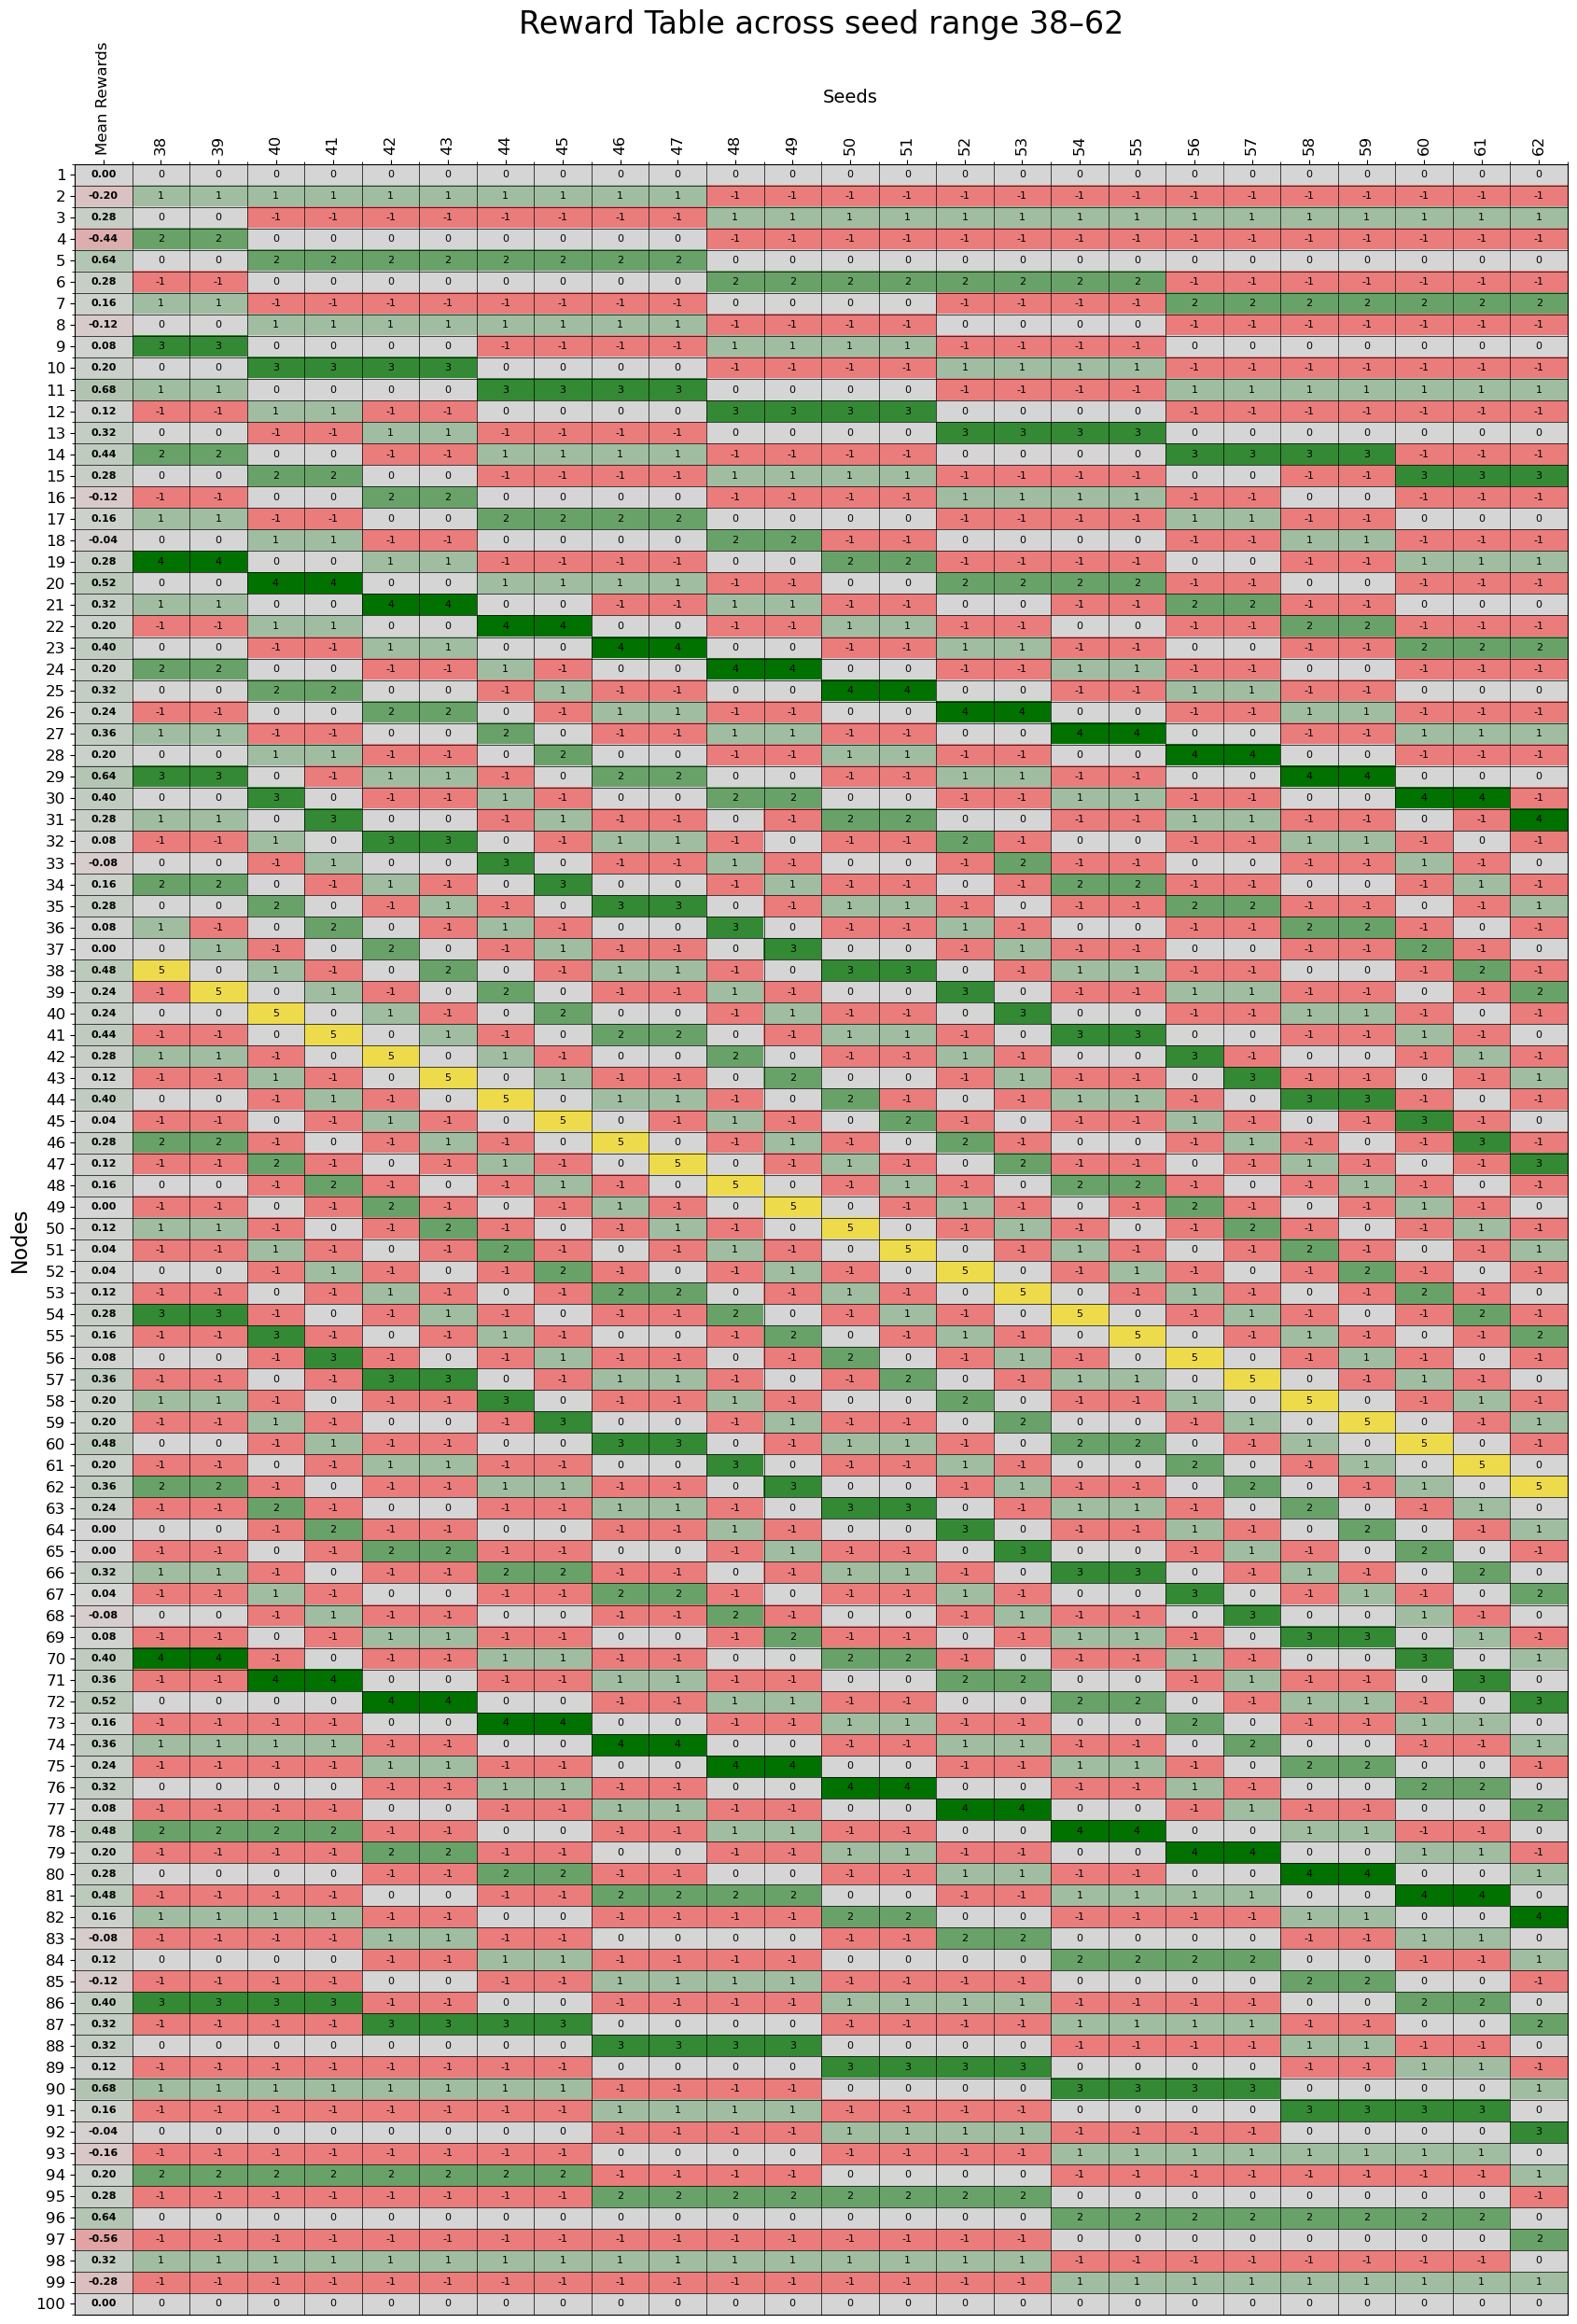

In [4]:
# ----------- Comprehensive result table for all node rewards over a suitable seed range ---------------
weights = np.random.randint(1, 10, len(all_seeds)) #or weights = None

reward_table() 

In [40]:
# ----------- Use and objective function to minimise rms and negative values ----------

def custom_weighting(weights=None):
    if weights is None:
        weights = np.ones(len(all_seeds))
    rewards, weighted_avg = node_avg(weights=weights)
    
    avg_reward = np.mean(rewards) #0.20 in base senario
    
    def objective(w):
        _, weighted_avg = node_avg(weights=w)
        
        rms =  np.mean((weighted_avg-avg_reward)**2) #punishes rewards deviating from midpoint
        
        negatives = weighted_avg[weighted_avg < 0]  #isolates negative rewards
        negativity_objective = np.mean(negatives**2)  #punishes large negative rewards
        
        objective = rms * negativity_objective
        sensitivity = 1e3
        

        return sensitivity * objective
    
    
    bounds = [(0, None)] * len(weights)
    optimized_weights = minimize(objective, weights, method='L-BFGS-B', bounds=bounds).x
    
    initial_obj = objective(weights)
    final_obj = objective(optimized_weights)

    print(f"Intial objective: {initial_obj:.4f}, Final objective: {final_obj:.4f}")

    return optimized_weights



Intial objective: 2.6731, Final objective: 1.4187
Updated weights are: [1.04095006 1.09474535 0.87666541 1.026137   1.23374197 1.10923476
 1.02228568 0.97650062 0.92008466 0.93589844 0.93321431 0.74330614
 0.47059563 0.48643172 0.81100255 1.00617587 0.96185707 0.98401462
 1.06822362 1.06997024 1.14621346 1.21310003 1.1611669  0.85630436
 1.614121  ]


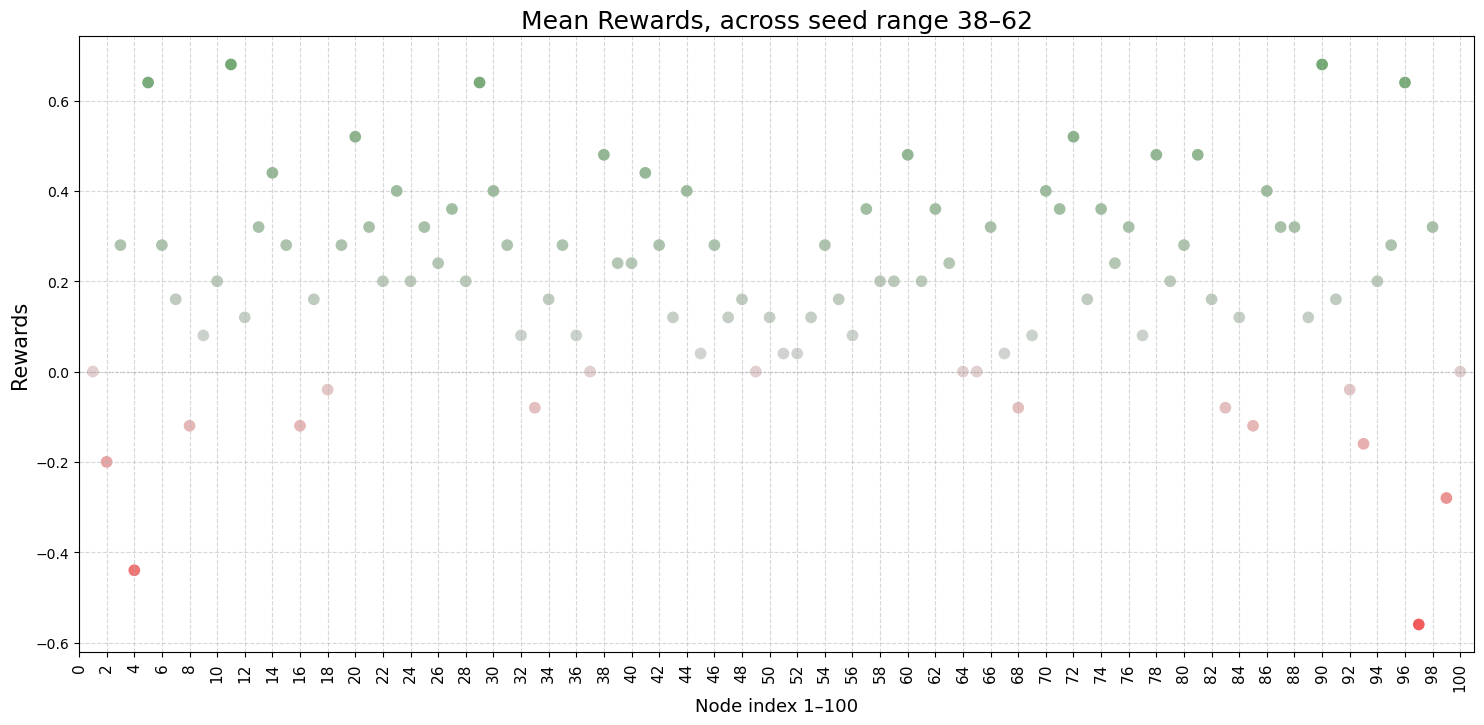

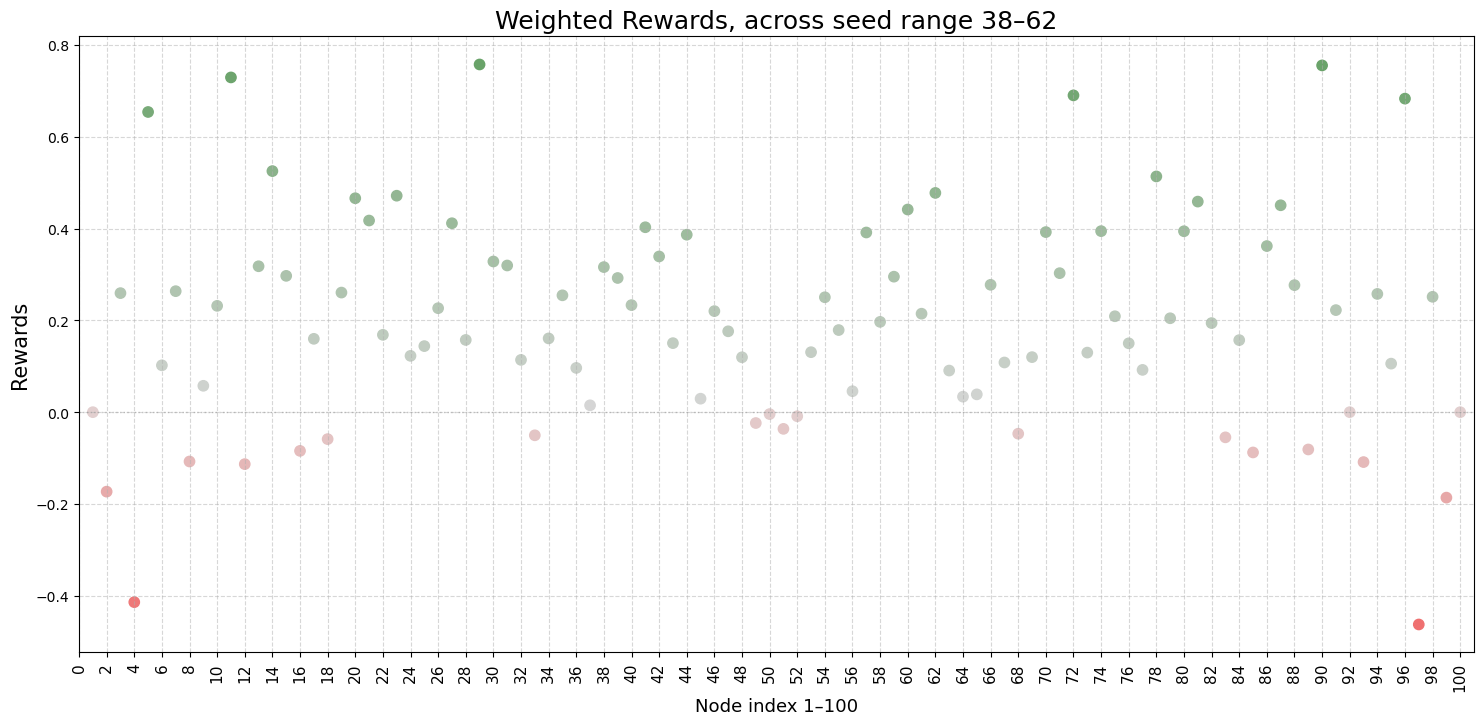

In [41]:
# ----------- Graphs showing expected rewards for A). equal seed weighting, B). custom seed weighting ----------
weights = custom_weighting()
print("Updated weights are:", weights)
reward_graph()
reward_graph(weights=weights)
#[1.04095006 1.09474535 0.87666541 1.026137   1.23374197 1.10923476
 #1.02228568 0.97650062 0.92008466 0.93589844 0.93321431 0.74330614
 #0.47059563 0.48643172 0.81100255 1.00617587 0.96185707 0.98401462
 #1.06822362 1.06997024 1.14621346 1.21310003 1.1611669  0.85630436
 #1.614121  ]

In [42]:
# ----------- A pandas table showing data about the choices made when choosing the lower or upper middle -----------
# ----------- A pandas table showing data about the choices made when choosing the lower or upper middle -----------
def tracking_table(table_data, rewards, seed, optimisations=None, weights=None):
    # Compute average rewards (weighted or not)
    _, avg_rewards = node_avg(weights=weights)

    # Convert table_data into DataFrame
    df = pd.DataFrame(table_data)
    df = df.dropna(how="all", subset=[
        "(L) lower middle","(L) upper middle","(L) choice",
        "(U) lower middle","(U) upper middle","(U) choice"
    ])

    # Sort by parent reward and parent index
    df["Reward"] = df["Parent"].apply(lambda x: rewards[int(x)-1])
    df.sort_values(by=["Reward","Parent"], ascending=[False, True], inplace=True)
    df.drop(columns=["Reward"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df_display = df.fillna("-")
    num_rows, num_cols = df_display.shape

    # Bold cells affected by optimisations
    fontweights = [["normal"]*num_cols for _ in range(num_rows)]
    if optimisations:
        for row_idx, row in df.iterrows():
            parent_val = int(row["Parent"])
            for s, p, lower_rule, upper_rule in optimisations:
                if s == seed and p == parent_val:
                    if lower_rule is not None:
                        col_idx = df_display.columns.get_loc("(L) choice")
                        fontweights[row_idx][col_idx] = "bold"
                    if upper_rule is not None:
                        col_idx = df_display.columns.get_loc("(U) choice")
                        fontweights[row_idx][col_idx] = "bold"
                    break

    # Cell colors
    cell_colors = []
    for row_idx, row in df.iterrows():
        parent_val = int(row["Parent"])
        row_colors = []
        for col in df.columns:
            val = row[col]
            if col == "Parent":
                color = Clr1(Norm1(rewards[parent_val - 1]))
            else:
                try:
                    node_val = int(val)
                    color = Clr2(Norm2(avg_rewards[node_val - 1]))
                except:
                    color = "white"
            row_colors.append(color)
        cell_colors.append(row_colors)

    # Plot table
    fig_width = max(num_cols*1.0, 14)
    fig_height = num_rows*0.25 + 2
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    table = ax.table(cellText=df_display.values,
                     colLabels=df_display.columns,
                     cellColours=cell_colors,
                     cellLoc='center',
                     loc='center')

    # Apply fontweight and 0 dp formatting
    for row in range(num_rows):
        for col in range(num_cols):
            cell = table[row+1, col]  # +1 for header
            cell.get_text().set_fontweight(fontweights[row][col])
            text = cell.get_text().get_text()
            try:
                val = float(text)
                cell.get_text().set_text(f"{val:.0f}")
            except ValueError:
                pass

    ax.axis('off')
    plt.title("BST Branch Tracking Table (Node Strength Colored)", fontsize=16)
    plt.subplots_adjust(top=1, bottom=0)

    # Branch headers
    ax.text(0.36, 0.89, "Lower Branch", fontsize=12, ha="center", va="top")
    ax.text(0.78, 0.89, "Upper Branch", fontsize=12, ha="center", va="top")
    plt.show()


# ----------- Seed slider update -----------
def seed_slider_update(seed):
    rewards, table_data = build_bst(seed, track_table=True)
    tracking_table(table_data, rewards, seed, optimisations=optimise_data)  # pass optimisations explicitly

widgets.interact(seed_slider_update, seed=slider)


     
         

interactive(children=(IntSlider(value=50, continuous_update=False, description='Seed:', layout=Layout(width='9…

<function __main__.seed_slider_update(seed)>

In [8]:
def generate_optimisations_for_all_seeds(seed_range):
    all_optimisations = []

    for seed in seed_range:
        rewards, table_data = build_bst(seed, track_table=True)
        
        for row in table_data:
            parent = row["Parent"]
            lower_rule = None
            upper_rule = None
            
            # ---- Lower Branch ----
            lower_options = []
            if row.get("(L) lower middle") is not None:
                lower_options.append(("down", row["(L) lower middle"]))
            if row.get("(L) upper middle") is not None:
                lower_options.append(("up", row["(L) upper middle"]))
            if lower_options:
                best_lower = min(lower_options, key=lambda x: rewards[int(x[1])-1])
                lower_rule = best_lower[0]
            
            # ---- Upper Branch ----
            upper_options = []
            if row.get("(U) lower middle") is not None:
                upper_options.append(("down", row["(U) lower middle"]))
            if row.get("(U) upper middle") is not None:
                upper_options.append(("up", row["(U) upper middle"]))
            if upper_options:
                best_upper = min(upper_options, key=lambda x: rewards[int(x[1])-1])
                upper_rule = best_upper[0]
            
            # Append to the optimisations list
            all_optimisations.append((seed, parent, lower_rule, upper_rule))
    
    return all_optimisations


all_seeds = range(38, 63)
optimisations_all_seeds = generate_optimisations_for_all_seeds(all_seeds)

# Print first 10 entries to check
print(optimisations_all_seeds)


[(38, 38, None, 'down'), (38, 19, 'up', 'down'), (38, 70, None, 'down'), (38, 9, 'up', None), (38, 29, None, 'down'), (38, 86, None, 'down'), (38, 4, None, 'down'), (38, 14, 'up', 'down'), (38, 24, 'up', 'down'), (38, 34, 'up', None), (38, 94, None, 'down'), (38, 7, 'up', None), (38, 11, None, 'down'), (38, 17, 'up', None), (38, 21, None, 'down'), (38, 27, 'up', None), (38, 31, None, 'down'), (38, 98, None, 'down'), (39, 39, 'up', None), (39, 19, 'up', None), (39, 70, 'up', 'down'), (39, 9, 'up', None), (39, 54, 'up', None), (39, 86, None, 'down'), (39, 4, None, 'down'), (39, 14, 'up', 'down'), (39, 24, 'up', 'down'), (39, 34, 'up', 'down'), (39, 46, 'up', None), (39, 94, None, 'down'), (39, 7, 'up', None), (39, 11, None, 'down'), (39, 17, 'up', None), (39, 21, None, 'down'), (39, 27, 'up', None), (39, 31, None, 'down'), (39, 37, 'up', None), (39, 42, 'up', None), (39, 98, None, 'down'), (40, 40, None, 'down'), (40, 71, 'up', None), (40, 55, 'up', None), (40, 86, 'up', 'down'), (40, 5,

In [9]:
import numpy as np
from copy import deepcopy

def hierarchical_optimisation(seed, max_depth=None, verbose=True):
    """
    Hierarchically optimizes BST branch decisions (up/down) from shallow to deep.
    Works even if 'Depth' is not present in the tracking table.
    """
    
    # --- Build baseline tree ---
    base_rewards, table_data = build_bst(seed, track_table=True)
    best_score = np.mean(base_rewards)
    best_opt = {}

    # Try to infer node depth information
    if "Depth" in table_data[0]:
        depth_lookup = {row["Parent"]: row["Depth"] for row in table_data}
    elif "Parent depth" in table_data[0]:
        depth_lookup = {row["Parent"]: row["Parent depth"] for row in table_data}
    else:
        # fallback: estimate by parent chain length
        # parents closer to root (seed) will have shorter chains
        depth_lookup = {}
        for row in table_data:
            parent = row["Parent"]
            if parent == seed:
                depth_lookup[parent] = 1
            else:
                depth_lookup[parent] = depth_lookup.get(parent, 1) + 1

    # determine maximum depth
    if max_depth is None:
        max_depth = max(depth_lookup.values())

    if verbose:
        print(f"\nOptimizing seed {seed} up to depth {max_depth}...")
        print(f"Initial mean reward: {best_score:.3f}")

    # --- Iterate by depth ---
    for depth in range(1, max_depth + 1):
        depth_parents = [p for p, d in depth_lookup.items() if d == depth]
        if not depth_parents:
            continue

        if verbose:
            print(f"  Depth {depth}: testing {len(depth_parents)} parents")

        for parent in depth_parents:
            # Get the row for this parent
            row = next((r for r in table_data if r["Parent"] == parent), None)
            if row is None:
                continue

            for branch_prefix, label in [("(L)", "lower"), ("(U)", "upper")]:
                # Skip if this branch doesn't exist
                if row.get(f"{branch_prefix} lower middle") is None and row.get(f"{branch_prefix} upper middle") is None:
                    continue

                current_best = best_score
                current_best_rule = None

                for rule in ["up", "down"]:
                    trial_opt = deepcopy(best_opt)
                    trial_opt[(seed, parent, label)] = rule

                    trial_rewards = build_bst(seed, optimisations=trial_opt)
                    trial_score = np.mean(trial_rewards)

                    if trial_score > current_best:
                        current_best = trial_score
                        current_best_rule = rule

                if current_best_rule is not None:
                    best_opt[(seed, parent, label)] = current_best_rule
                    best_score = current_best
                    if verbose:
                        print(f"    → Improved {label} branch of parent {parent} → {current_best_rule.upper()} "
                              f"(mean reward {best_score:.3f})")

    if verbose:
        print(f"✅ Optimization complete. Final mean reward: {best_score:.3f}\n")

    return best_opt, best_score



seed = 50
best_rules, best_score = hierarchical_optimisation(seed)

print("Best rules found:")
for (seed, parent, branch), rule in best_rules.items():
    print(f"Seed {seed}, Parent {parent}, Branch {branch} → {rule}")



Optimizing seed 50 up to depth 2...
Initial mean reward: 0.200
  Depth 1: testing 1 parents
  Depth 2: testing 27 parents
✅ Optimization complete. Final mean reward: 0.200

Best rules found:
